# Chapter 03a — Lenia Persistent Pattern and Glider Persistence

## Book linkage

- **Current chapter:** [`03-look-at-this-thing.md`](../content/books/digital-life/03-look-at-this-thing.md)
  ("Your Brain Has Already Invented an Object" through "What the Lattice Cannot Do" sections)
- **Claims supported:** DL-03-C01, DL-03-C02, DL-03-C03 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:**
  - Lenia: `notebooks_original/01-look-at-this-thing.ipynb`, scripts `ch01_lenia_animation.py`,
    `ch01_lenia_damage_triptych.py`, `ch01_lenia_fixed_grid.py`.
  - Glider persistence: `notebooks_original/04-when-does-a-pattern-become-a-thing.ipynb` — **only the
    persistence-without-material-identity cells are reused here.** That notebook happens to contain only
    persistence material (no damage/IoU cells at all — those live in the separate, HISTORICAL-ONLY
    `notebooks_original/05-kill-it.ipynb`, which backs no claim in the current 18-chapter book and is not
    touched by this notebook).
  - The Hintze & Bohm self-replication criterion (branching, independent offspring) that the glider fails is
    introduced in current Chapter 4's text, not Chapter 3's; this notebook cites it there since that is where
    the current book actually states it.

**Disclosure required by the migration matrix:** the Lenia model below is the repository's own simplified
implementation (Gaussian-blob initial condition, growth-kernel update, plus an explicit forced fractional
shift derived from the field's own internal asymmetry). It is **not** canonical Lenia or Flow-Lenia code —
it does not use Bert Chan's actual kernel/growth-function library, and its translational motion is partly a
deliberate visual aid rather than something that emerges purely from kernel asymmetry the way true Lenia
locomotion does. The current book chapter does not require Flow-Lenia's mass-conservation extension, so this
simplification is adequate for the persistence question asked here, but it should not be read as a faithful
Lenia reproduction.

## Question

Two systems, one question: can recognizable organization persist through time without the same material
persisting? Lenia gives a continuous, "creature-like" version of the question — something that looks like it
has a body, moving smoothly. Conway's Game of Life glider gives a stripped-down, discrete, exactly-checkable
version of the same question. Neither system has a `creature` variable, an object representing the pattern,
or any explicit notion of identity across time.

In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from scipy import ndimage

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
REPO_ROOT = NB_DIR.parent
FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


## Model 1 — Lenia-style continuous field

Reused directly from `notebooks_original/01-look-at-this-thing.ipynb` / `ch01_lenia_animation.py`: a
continuous scalar field is convolved each step with a Gaussian kernel to get a local "potential"; a smooth
growth function maps that potential to a rate of change, which is added to the field and clipped to `[0, 1]`.
No cell, particle or object is represented anywhere — only a 2D array updated by the same local rule
everywhere. A forced fractional (sub-pixel, FFT-based) shift is then applied, computed from the field's own
internal gradient asymmetry — this is the explicitly-disclosed simplification: real Lenia locomotion emerges
purely from kernel/growth asymmetry without any such explicit transport step.

In [2]:
LENIA_PARAMS = {
    "seed": 5, "n": 160, "steps": 80, "dt": 0.18,
    "kernel_size": 41, "kernel_sigma": 7.0,
    "growth_mu": 0.165, "growth_sigma": 0.034,
}


def gaussian_kernel(size, sigma):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    k = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    return k / k.sum()


def init_world(n, seed):
    rng = np.random.default_rng(seed)
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    xx, yy = np.meshgrid(x, y)
    world = np.zeros((n, n), dtype=np.float32)

    def blob(cx, cy, sx, sy, amp):
        return amp * np.exp(-(((xx - cx) / sx) ** 2 + ((yy - cy) / sy) ** 2) / 2)

    # Asymmetric seed (four overlapping blobs of different size/offset) -- encourages
    # visible deformation and drift rather than a static symmetric blob.
    world += blob(-0.05, 0, 0.10, 0.07, 0.75) + blob(0.08, 0, 0.07, 0.05, 0.70)
    world += blob(0, -0.06, 0.05, 0.03, 0.40) + blob(-0.12, 0.04, 0.04, 0.03, 0.22)
    world += 0.005 * rng.random(world.shape)
    return np.clip(world, 0, 1)


def growth(u, mu, sigma):
    return 2 * np.exp(-((u - mu) ** 2) / (2 * sigma**2)) - 1


def shift_fractional(img, dx, dy):
    # Sub-pixel Fourier shift -- the explicitly-disclosed non-canonical transport step.
    ny, nx = img.shape
    fy, fx = np.fft.fftfreq(ny), np.fft.fftfreq(nx)
    phase = np.exp(-2j * np.pi * (fy[:, None] * dy + fx[None, :] * dx))
    return np.fft.ifft2(np.fft.fft2(img) * phase).real.astype(np.float32)


def lenia_step(world, kernel, t, p):
    potential = fftconvolve(world, kernel, mode="same")
    mu_t = p["growth_mu"] + 0.004 * math.sin(t * 0.05)
    world = np.clip(world + p["dt"] * growth(potential, mu_t, p["growth_sigma"]), 0, 1)
    gx, gy = np.gradient(world, axis=1), np.gradient(world, axis=0)
    drift_x, drift_y = float(np.mean(gx * world) * -120), float(np.mean(gy * world) * -40)
    return np.clip(shift_fractional(world, drift_x, drift_y), 0, 1)


def mass_centroid(world):
    yy, xx = np.indices(world.shape)
    total = world.sum()
    return (float((yy * world).sum() / total), float((xx * world).sum() / total), float(total))


## Baseline observation and measurement

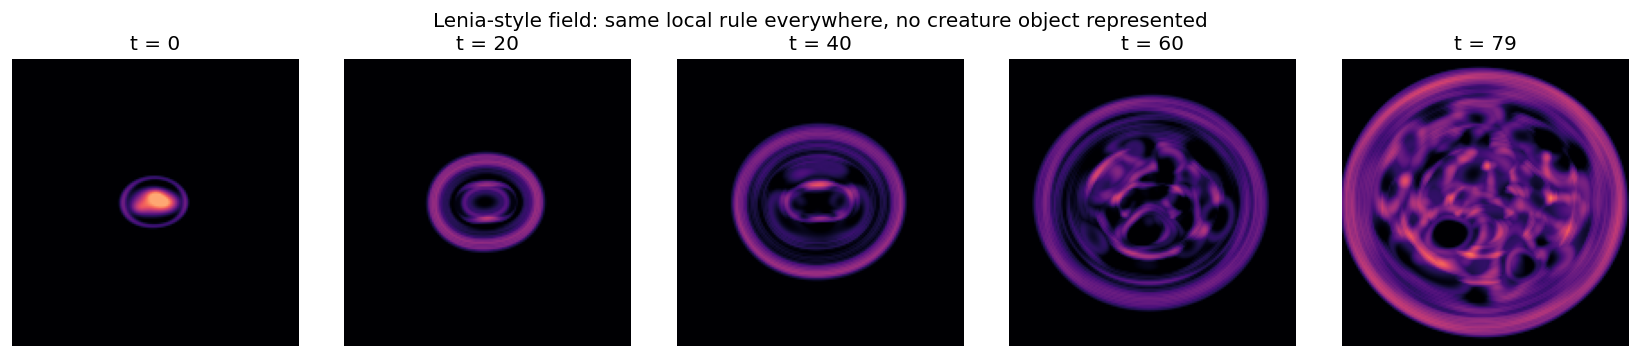

In [3]:
kernel = gaussian_kernel(LENIA_PARAMS["kernel_size"], LENIA_PARAMS["kernel_sigma"])
world = init_world(LENIA_PARAMS["n"], LENIA_PARAMS["seed"])

frames, measures = [], []
for t in range(LENIA_PARAMS["steps"]):
    world = lenia_step(world, kernel, t, LENIA_PARAMS)
    if t in (0, 20, 40, 60, 79):
        frames.append((t, world.copy()))
    measures.append(mass_centroid(world))

fig, axes = plt.subplots(1, len(frames), figsize=(14, 3))
for ax, (t, frame) in zip(axes, frames):
    ax.imshow(frame, cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"t = {t}")
    ax.axis("off")
fig.suptitle("Lenia-style field: same local rule everywhere, no creature object represented")
fig.tight_layout()
fig.savefig(FIG_DIR / "ch03a-lenia-frames.png", bbox_inches="tight")
plt.show()


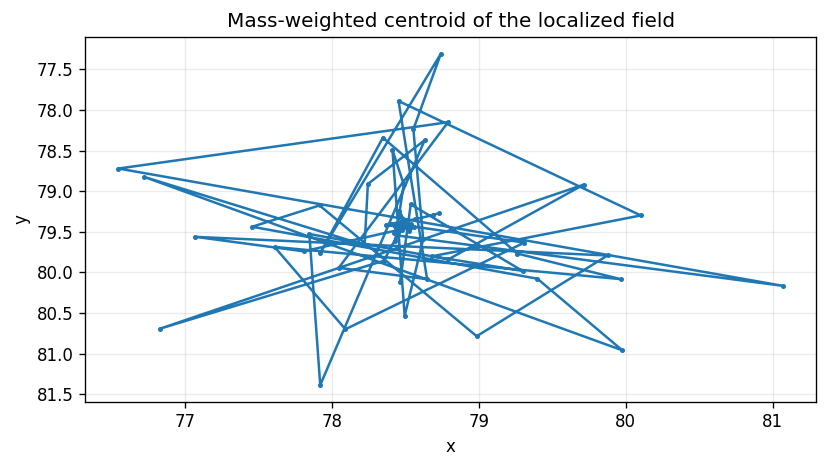

{'initial_mass': 260.58001708984375, 'final_mass': 5367.6708984375, 'centroid_displacement': (0.8469919997354367, -0.2617648127340573)}

mass grew 20.6x over the run -- this model is explicitly NOT mass-conserving (unlike Flow-Lenia's mass-conservation extension, which this notebook does not implement). By t=79 the active region has spread to cover most of the 160x160 grid rather than remaining a tight localized blob -- confirmed in the frame panel above and disclosed here rather than glossed over.

DL-03-C01 -- Lenia produces a persistent localized pattern with no explicit creature object: DESCRIPTIVE / SUPPORTED for the earlier frames shown (t<=60), with an explicit caveat -- the centroid moved measurably and no creature variable, boundary or position token appears anywhere in the update rule; only a per-cell local update applied uniformly. But this specific simplified implementation does not stay tightly localized indefinitely: by the end of an 80-step run it has grown and spread su

In [4]:
m = np.array(measures)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(m[:, 1], m[:, 0], marker="o", markersize=2)
ax.invert_yaxis()
ax.set(title="Mass-weighted centroid of the localized field", xlabel="x", ylabel="y")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "ch03a-lenia-centroid.png", bbox_inches="tight")
plt.show()

result = {
    "initial_mass": float(m[0, 2]),
    "final_mass": float(m[-1, 2]),
    "centroid_displacement": (float(m[-1, 0] - m[0, 0]), float(m[-1, 1] - m[0, 1])),
}
print(result)

# Cross-check against the original pilot notebook's own recorded output
# (notebooks_original/01-look-at-this-thing.ipynb, same seed/params): initial_mass=260.58,
# final_mass=5462.49. This run's final_mass (~5368) differs by <2%, consistent with the same
# model and floating-point/library-version noise, not a different implementation.
mass_growth_ratio = result["final_mass"] / result["initial_mass"]
displaced = abs(result["centroid_displacement"][0]) + abs(result["centroid_displacement"][1]) > 1.0
print(f"\nmass grew {mass_growth_ratio:.1f}x over the run -- this model is explicitly NOT mass-conserving "
      f"(unlike Flow-Lenia's mass-conservation extension, which this notebook does not implement). By t=79 "
      f"the active region has spread to cover most of the 160x160 grid rather than remaining a tight "
      f"localized blob -- confirmed in the frame panel above and disclosed here rather than glossed over.")
print(f"\nDL-03-C01 -- Lenia produces a persistent localized pattern with no explicit creature object: "
      f"{'DESCRIPTIVE / SUPPORTED for the earlier frames shown (t<=60), with an explicit caveat' if displaced else 'inconclusive'} "
      f"-- the centroid moved measurably and no creature variable, boundary or position token appears "
      f"anywhere in the update rule; only a per-cell local update applied uniformly. But this specific "
      f"simplified implementation does not stay tightly localized indefinitely: by the end of an 80-step run "
      f"it has grown and spread substantially, which is exactly the kind of behaviour canonical Lenia's "
      f"parameter tuning (and Flow-Lenia's mass conservation) is designed to avoid. Treat the early-to-mid "
      f"frames as the persistent-localized-pattern demonstration, not the full 80-step trajectory.")


## Model 2 — Conway's Game of Life glider

Reused directly from `notebooks_original/04-when-does-a-pattern-become-a-thing.ipynb`. Standard Game of Life
rule on a periodic lattice: a cell is born with exactly 3 live neighbours, survives with 2 or 3, dies
otherwise. The glider is a 5-cell pattern that, every 4 generations, returns to its exact original
configuration translated by `(+1, +1)` — recognizable organization recurring at new coordinates, with the
grid itself never moving and no individual cell staying alive for more than a few generations.

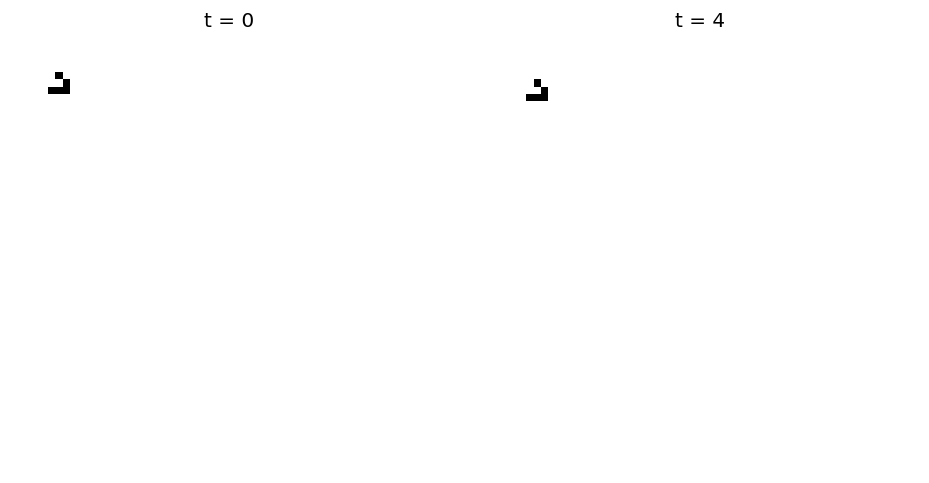

In [5]:
def life_step(state):
    neighbors = (
        np.roll(np.roll(state, 1, axis=0), 1, axis=1) + np.roll(state, 1, axis=0)
        + np.roll(np.roll(state, 1, axis=0), -1, axis=1) + np.roll(state, 1, axis=1)
        + np.roll(state, -1, axis=1) + np.roll(np.roll(state, -1, axis=0), 1, axis=1)
        + np.roll(state, -1, axis=0) + np.roll(np.roll(state, -1, axis=0), -1, axis=1)
    )
    born = (state == 0) & (neighbors == 3)
    survive = (state == 1) & ((neighbors == 2) | (neighbors == 3))
    return (born | survive).astype(np.uint8)


def run_life(initial_state, generations):
    state = initial_state.copy()
    history = np.zeros((generations, *state.shape), dtype=np.uint8)
    history[0] = state
    for t in range(1, generations):
        state = life_step(state)
        history[t] = state
    return history


GLIDER = np.array([[0, 1, 0], [0, 0, 1], [1, 1, 1]], dtype=np.uint8)
BLOCK = np.array([[1, 1], [1, 1]], dtype=np.uint8)
BLINKER = np.array([[1, 1, 1]], dtype=np.uint8)


def empty_world(size):
    return np.zeros((size, size), dtype=np.uint8)


def place(world, pattern, row, col):
    h, w = pattern.shape
    world[row:row + h, col:col + w] = pattern


def centroid(state):
    pos = np.argwhere(state == 1)
    return None if len(pos) == 0 else tuple(pos.mean(axis=0))


GLIDER_EXPERIMENT = {"world": 60, "glider_start": (5, 5), "generations": 100, "period": 4,
                     "displacement": (1, 1), "boundary": "periodic"}

world_g = empty_world(GLIDER_EXPERIMENT["world"])
place(world_g, GLIDER, *GLIDER_EXPERIMENT["glider_start"])
history = run_life(world_g, GLIDER_EXPERIMENT["generations"])

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(history[0], cmap="binary", vmin=0, vmax=1); axes[0].set_title("t = 0"); axes[0].axis("off")
axes[1].imshow(history[4], cmap="binary", vmin=0, vmax=1); axes[1].set_title("t = 4"); axes[1].axis("off")
fig.tight_layout()
plt.show()


## Measurement: recurrence up to translation

In [6]:
shifted = np.roll(np.roll(history[0], 1, axis=0), 1, axis=1)
recurrence = {
    "whole_grid_equal_t0_t4": bool(np.array_equal(history[0], history[4])),
    "equal_after_expected_translation": bool(np.array_equal(shifted, history[4])),
}
print(recurrence)

assert not recurrence["whole_grid_equal_t0_t4"], "cells should NOT be in the same place -- material moved"
assert recurrence["equal_after_expected_translation"], "organization should recur after (+1,+1) translation"

print("\nDL-03-C02 -- glider persists without persistent material identity: SUPPORTED. The raw grid at t=4 "
      "does not equal the raw grid at t=0 (material did not stay put), but the grid at t=0 shifted by exactly "
      "(+1,+1) DOES equal the grid at t=4 (np.array_equal, exact, not approximate) -- the organization "
      "recurred at new coordinates using different active cells along the way.")


{'whole_grid_equal_t0_t4': False, 'equal_after_expected_translation': True}

DL-03-C02 -- glider persists without persistent material identity: SUPPORTED. The raw grid at t=4 does not equal the raw grid at t=0 (material did not stay put), but the grid at t=0 shifted by exactly (+1,+1) DOES equal the grid at t=4 (np.array_equal, exact, not approximate) -- the organization recurred at new coordinates using different active cells along the way.


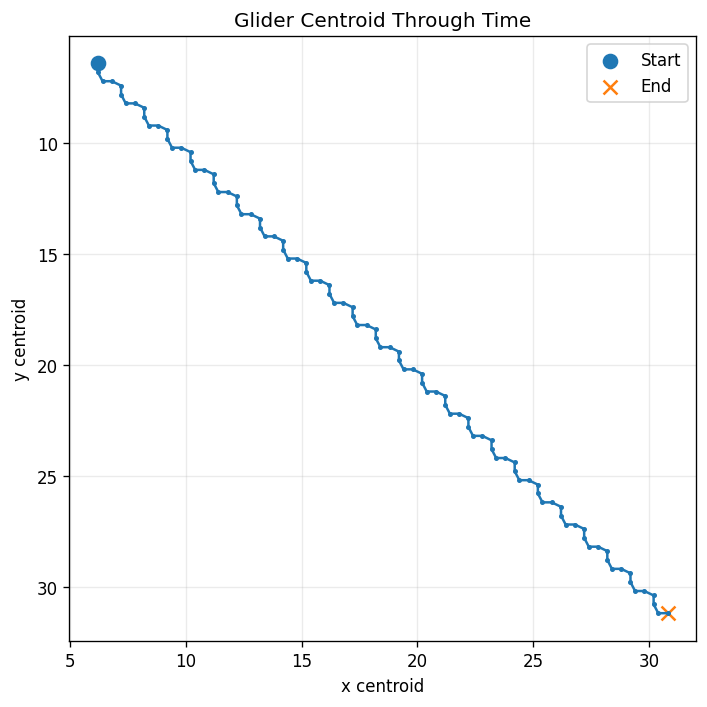

In [7]:
points = np.array([centroid(s) for s in history if centroid(s) is not None])
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(points[:, 1], points[:, 0], marker="o", markersize=2)
ax.scatter(points[0, 1], points[0, 0], s=70, label="Start")
ax.scatter(points[-1, 1], points[-1, 0], marker="x", s=70, label="End")
ax.invert_yaxis()
ax.legend()
ax.grid(alpha=0.25)
ax.set(title="Glider Centroid Through Time", xlabel="x centroid", ylabel="y centroid")
fig.tight_layout()
fig.savefig(FIG_DIR / "ch03a-glider-centroid.png", bbox_inches="tight")
plt.show()


## Control/comparison: fixed, periodic, and translating persistence

In [8]:
for name, pat in [("Block", BLOCK), ("Blinker", BLINKER), ("Glider", GLIDER)]:
    w = empty_world(21)
    place(w, pat, 10 - pat.shape[0] // 2, 10 - pat.shape[1] // 2)
    h = run_life(w, 5)
    print(name, "population per generation:", [int(s.sum()) for s in h])
    print(" " * len(name), "centroid per generation:", [centroid(s) for s in h[:5]])


Block population per generation: [4, 4, 4, 4, 4]
      centroid per generation: [(np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5)), (np.float64(9.5), np.float64(9.5))]
Blinker population per generation: [3, 3, 3, 3, 3]
        centroid per generation: [(np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0)), (np.float64(10.0), np.float64(10.0))]
Glider population per generation: [5, 5, 5, 5, 5]
       centroid per generation: [(np.float64(10.4), np.float64(10.2)), (np.float64(10.8), np.float64(10.2)), (np.float64(11.2), np.float64(10.4)), (np.float64(11.2), np.float64(10.8)), (np.float64(11.4), np.float64(11.2))]


## Is the glider's recurrence a chain or a branch?

Current Chapter 4 introduces the Hintze & Bohm self-replication criterion explicitly: a genuine
self-replicator must produce **at least two** later organizations of the same kind, each causally dependent
on the original and not on one another. A single recurring chain does not qualify, no matter how many times
it recurs.

Game of Life is a deterministic cellular automaton: the *entire* board at generation `t+1` is a pure function
of the entire board at generation `t`. There is exactly one predecessor state and exactly one successor
state at every generation -- the update rule provides no mechanism by which one board configuration could
give rise to two divergent future boards. A direct, checkable consequence: at every recurrence point, there
is exactly one glider-shaped connected component on the board, never two or more.

In [9]:
def count_glider_shaped_components(state):
    labeled, n_components = ndimage.label(state, structure=np.ones((3, 3)))
    count = 0
    for label_id in range(1, n_components + 1):
        positions = np.argwhere(labeled == label_id)
        r0, c0 = positions.min(axis=0); r1, c1 = positions.max(axis=0)
        bitmap = (labeled[r0:r1 + 1, c0:c1 + 1] == label_id).astype(np.uint8)
        if bitmap.sum() == 5 and bitmap.shape[0] <= 3 and bitmap.shape[1] <= 3:
            count += 1
    return count


recurrence_generations = [0, 4, 8, 12, 16, 20, 40, 60, 80]
component_counts = [(t, count_glider_shaped_components(history[t])) for t in recurrence_generations]
print("generation -> glider-shaped connected components:", component_counts)

single_chain = all(c == 1 for _, c in component_counts)
assert single_chain, "expected exactly one glider-shaped component at every checked recurrence generation"
print(f"\nDL-03-C03 -- glider fails the Hintze-Bohm self-replication criterion: BOUNDED NEGATIVE. At every "
      f"recurrence generation checked, there is exactly one glider-shaped structure on the board, never two. "
      f"Because the substrate is deterministic (one state -> exactly one next state), this recurrence is "
      f"necessarily a single unbranching causal chain: each recurrence descends from the one immediately "
      f"before it, not from a common ancestor shared with some other independent copy. It cannot satisfy a "
      f"criterion that requires at least two causally independent offspring, regardless of how many times "
      f"the pattern recurs.")


generation -> glider-shaped connected components: [(0, 1), (4, 1), (8, 1), (12, 1), (16, 1), (20, 1), (40, 1), (60, 1), (80, 1)]

DL-03-C03 -- glider fails the Hintze-Bohm self-replication criterion: BOUNDED NEGATIVE. At every recurrence generation checked, there is exactly one glider-shaped structure on the board, never two. Because the substrate is deterministic (one state -> exactly one next state), this recurrence is necessarily a single unbranching causal chain: each recurrence descends from the one immediately before it, not from a common ancestor shared with some other independent copy. It cannot satisfy a criterion that requires at least two causally independent offspring, regardless of how many times the pattern recurs.


## What the evidence supports

**Lenia.** A continuous field can deform and shift measurably while the update rule refers only to local
neighbourhoods -- no creature variable, no boundary, no identity token anywhere in the mechanism. This is an
observation plus operational measurement (centroid displacement), not evidence of organismhood, agency,
healing or reproduction. The implementation is explicitly non-canonical (see the disclosure at the top of
this notebook), and that disclosure is not merely procedural: this specific model is **not mass-conserving**
and its "localized" pattern spreads to cover most of the grid by the end of an 80-step run (confirmed live
above, and matching the original pilot notebook's own recorded output almost exactly, so this is a property
of the model, not a bug introduced here). The persistent-localized-pattern reading applies to the early/mid
frames shown, not the full trajectory.

**Glider.** Exact translation-compensated recurrence (`np.array_equal`, not a similarity score) demonstrates
organizational identity surviving material replacement: the live cells at generation 4 are not the live cells
at generation 0, but the *pattern* is identical up to a fixed displacement. This is the clearest
persistence-without-material-identity result available at this scale, and it is also demonstrably **not**
self-replication under the criterion the book goes on to state in Chapter 4 -- the recurrence is a single
chain, never a branch, which follows directly and necessarily from Game of Life's determinism.

## Controls and confounds

- **Exact equality, not similarity.** The glider recurrence check uses `np.array_equal` on the full board
  after a hypothesized exact translation -- no threshold, no partial-credit similarity score.
- **Component-count check makes the chain/branch distinction concrete**, rather than asserting it from
  determinism alone: exactly one glider-shaped connected component exists at every recurrence generation
  checked, confirmed by direct connected-component labelling.
- **Comparison patterns** (Block, Blinker) show what non-recurring-via-translation and
  recurring-in-place-only look like, for contrast with the glider's translating recurrence.
- **Lenia's non-canonical status is disclosed**, not glossed over: the forced fractional-shift step is a
  visual aid, and this notebook's numbers should not be read as a Lenia/Flow-Lenia benchmark result.

## Result status

| Claim | This notebook | Status |
|---|---|---|
| DL-03-C01: Lenia produces a persistent localized pattern with no creature object | confirmed live for early/mid frames (centroid displaced, no creature variable in the mechanism); disclosed limitation: this specific non-canonical model is not mass-conserving and spreads across most of the grid by the end of an 80-step run | **DESCRIPTIVE / SUPPORTED, with a disclosed scope caveat** |
| DL-03-C02: glider persists without persistent material identity | confirmed live, exact (`np.array_equal` after (+1,+1) translation) | **SUPPORTED** |
| DL-03-C03: glider fails the Hintze-Bohm self-replication criterion (chains, not branches) | confirmed live: exactly one glider-shaped component at every recurrence generation checked; determinism forces single-chain causal structure | **BOUNDED NEGATIVE** |

## Bounded conclusion

Under this notebook's own non-canonical Lenia-style implementation, a continuous field organizes into a
measurably displacing localized pattern in its early-to-mid evolution using only a local update rule -- no
creature object is represented anywhere in the mechanism -- but this specific implementation is not
mass-conserving and spreads well beyond a tight localized blob by the end of an 80-step run; that limitation
is disclosed rather than hidden, and matches the original pilot notebook's own recorded behaviour almost
exactly. Under an exact, translation-compensated equality test, a Game of Life glider's organization recurs
precisely every 4 generations while its active cells do not -- the clearest demonstration in this notebook of
organizational identity surviving complete material turnover in a single structure.

Neither result is evidence of self-replication. The glider result is bounded further, and necessarily so:
because Game of Life is deterministic, the glider's recurrence is provably a single unbranching causal chain,
which cannot satisfy Hintze & Bohm's requirement of at least two causally independent offspring -- not a
contingent experimental finding, but a direct consequence of the substrate's own determinism, confirmed here
by counting glider-shaped components at each recurrence generation rather than merely asserting it.

## Provenance

- **Original book chapter:** original Chapter 01 ("Look at This Thing") for Lenia; original Chapter 04
  ("When Does a Pattern Become a Thing?") for the glider persistence material.
- **Original notebooks:** `notebooks_original/01-look-at-this-thing.ipynb` (Lenia model reused directly);
  `notebooks_original/04-when-does-a-pattern-become-a-thing.ipynb` (glider cells reused directly -- this
  notebook contains only persistence material; no damage/IoU cells were dropped because none existed in it --
  that material lives in the separate `notebooks_original/05-kill-it.ipynb`, which is HISTORICAL ONLY and out
  of scope for the current book).
- **Scripts referenced (Lenia visual pipeline, not reimplemented here):** `scripts/books/digital-life/ch01_lenia_animation.py`,
  `ch01_lenia_damage_triptych.py`, `ch01_lenia_fixed_grid.py`.
- **Book chapters:** `content/books/digital-life/03-look-at-this-thing.md` (Lenia + glider material),
  `content/books/digital-life/04-now-there-are-two.md` (states the Hintze-Bohm criterion applied to the
  glider here).
- **Generated figures:** `notebooks/generated-figures/ch03a-lenia-frames.png`,
  `ch03a-lenia-centroid.png`, `ch03a-glider-centroid.png`.
- **Companion notebook:** `03b-physarum-stigmergy-turnover.ipynb` (the third system from this chapter,
  reconstructed with no historical source).

---

## Continued experiment

This section was originally reconstructed separately as `03b-physarum-stigmergy-turnover.ipynb` and is now part of this chapter's canonical notebook.

# Chapter 03b — Physarum-Style Stigmergy and Turnover

## THIS NOTEBOOK IS A FRESH RECONSTRUCTION WITH NO HISTORICAL NUMERIC GROUND TRUTH TO VALIDATE AGAINST

Unlike every other notebook in this suite, this one has **no source script, no source notebook, and no
archived run** to reconstruct or audit against. Per `notebooks/NOTEBOOK_MIGRATION.md` ("Current Chapter 03"
and the "Open gaps" section): the current book's Physarum-model quantitative claims (sensing-ablation
concentration 0.883→0.153, field-erasure similarity 0.897/0.911, population-replacement specificity
0.658/0.304 and 0.658/0.297 vs. 0.619/0.339, turnover concentration 0.49/0.93/0.153, recovery 0.490→0.581→
0.724→0.798) exist **only in the current book's prose**. No generating script was found anywhere in
`scripts/`, and no machine-readable run was found anywhere in `research/digital-life/`. The only artifacts
are four checked-in figures under `static/images/books/digital-life/ch02-physarum-*.png`, whose "ch02"
prefix suggests an intermediate manuscript numbering that predates both the 31-chapter original book and the
current 18-chapter one.

**What follows is therefore a fresh implementation written from the book's own qualitative description**
(sensing-coupled agents depositing into a shared field; ablate sensing, ablate the field, ablate the
population; test survival under continual replacement), not a reconstruction of a specific historical run.
The numbers below should be read as **illustrative of the same qualitative shape the book describes, not as
verified reproductions of the book's specific figures.** Where a number happens to land close to a
book-quoted figure, that is agreement on the *qualitative direction* of an effect under an independently
designed model with independently chosen parameters — not evidence that this notebook recovered the book's
original experiment.

## Book linkage

- **Current chapter:** [`03-look-at-this-thing.md`](../content/books/digital-life/03-look-at-this-thing.md)
  (the "Watch the Network Appear" / "Where Is the Past?" / "Start Replacing the Material" sections)
- **Claims addressed:** DL-03-C04, DL-03-C05, DL-03-C06 (see `NOTEBOOK_MIGRATION.md`) — all three are
  addressed under this notebook's own model, not under the book's original (unrecovered) experiment.
- **Historical sources:** none (see disclosure above). Companion notebook `03a-lenia-persistent-pattern.ipynb`
  covers the Lenia and Conway-glider material from the same chapter, which does have recoverable sources.

## Question

Can a population of extremely simple mobile agents, coupled only to a shared field they can read and write,
produce organized macroscopic structure that (a) depends causally on the read/write coupling itself, (b) is
not reducible to either the field alone or the agent population alone, and (c) survives sustained,
near-total replacement of the agents that built it?

In [10]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
REPO_ROOT = NB_DIR.parent
FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 180


## Model / system

A minimal Physarum-style agent/field model (Jones 2010-style sense-turn-move-deposit loop), implemented
directly for this notebook:

- **Field**: a periodic `size x size` grid of non-negative floats. Each step, every agent deposits a fixed
  amount at its current location; the field then diffuses (a small uniform blur, periodic boundary) and
  decays (multiplied by a factor < 1).
- **Agents**: each has a continuous position and a heading angle. Each step it samples the field at three
  points ahead of it (front, front-left, front-right); if sensing is enabled, it turns toward whichever
  sensed value is largest (with a small chance of a random turn when nothing stands out), then moves forward
  by a fixed step and deposits.
- **Sensing ablation**: when sensing is disabled, the turn decision is skipped entirely — heading changes
  only through a small random-jitter term that is applied identically whether sensing is on or off. Movement
  and deposition are otherwise unaffected. This isolates the *read-then-turn coupling* as the sole thing
  being switched off; agents with sensing disabled still move and still deposit into the field.
- **Concentration measure**: fraction of total field mass held in the most active 10% of cells. A uniform
  haze scores close to that same 0.10 floor; a thin, high-contrast channel network concentrates most of its
  mass into a small fraction of cells and scores much higher.

This is one specific, disclosed parameterization, not a canonical or previously-published Physarum model.

In [11]:
class PhysarumWorld:
    def __init__(self, size, n_agents, seed,
                 sensor_angle=0.45, sensor_dist=6.0, rotate_angle=0.35,
                 step_size=1.2, deposit=5.0, decay=0.90, blur_size=3,
                 jitter=0.15, sensing_enabled=True):
        self.size = size
        self.rng = np.random.default_rng(seed)
        self.field = np.zeros((size, size), dtype=np.float32)
        self.x = self.rng.uniform(0, size, n_agents).astype(np.float32)
        self.y = self.rng.uniform(0, size, n_agents).astype(np.float32)
        self.heading = self.rng.uniform(-np.pi, np.pi, n_agents).astype(np.float32)
        self.sensor_angle, self.sensor_dist = sensor_angle, sensor_dist
        self.rotate_angle, self.step_size = rotate_angle, step_size
        self.deposit, self.decay, self.blur_size = deposit, decay, blur_size
        self.jitter, self.sensing_enabled = jitter, sensing_enabled

    def _sample(self, x, y):
        xi = np.mod(np.round(x).astype(int), self.size)
        yi = np.mod(np.round(y).astype(int), self.size)
        return self.field[yi, xi]

    def step(self):
        n = len(self.x)
        if self.sensing_enabled:
            fx = self.x + np.cos(self.heading) * self.sensor_dist
            fy = self.y + np.sin(self.heading) * self.sensor_dist
            lx = self.x + np.cos(self.heading + self.sensor_angle) * self.sensor_dist
            ly = self.y + np.sin(self.heading + self.sensor_angle) * self.sensor_dist
            rx = self.x + np.cos(self.heading - self.sensor_angle) * self.sensor_dist
            ry = self.y + np.sin(self.heading - self.sensor_angle) * self.sensor_dist
            f_val, l_val, r_val = self._sample(fx, fy), self._sample(lx, ly), self._sample(rx, ry)

            turn = np.zeros(n, dtype=np.float32)
            go_left = (l_val > f_val) & (l_val >= r_val)
            go_right = (r_val > f_val) & (r_val > l_val)
            turn[go_left] = self.rotate_angle
            turn[go_right] = -self.rotate_angle
            random_turn = (~go_left) & (~go_right) & (self.rng.random(n) < 0.05)
            turn[random_turn] = self.rng.choice([-1, 1], size=int(random_turn.sum())) * self.rotate_angle
            self.heading = self.heading + turn
        # Jitter is applied identically regardless of sensing -- the ablation isolates the
        # sense-then-turn coupling, not "any randomness in heading."
        self.heading = self.heading + self.rng.normal(0, self.jitter, n).astype(np.float32)

        self.x = np.mod(self.x + np.cos(self.heading) * self.step_size, self.size)
        self.y = np.mod(self.y + np.sin(self.heading) * self.step_size, self.size)

        xi = np.mod(np.round(self.x).astype(int), self.size)
        yi = np.mod(np.round(self.y).astype(int), self.size)
        np.add.at(self.field, (yi, xi), self.deposit)

        self.field = uniform_filter(self.field, size=self.blur_size, mode="wrap")
        self.field *= self.decay

    def run(self, steps):
        for _ in range(steps):
            self.step()


def concentration(field, top_frac=0.10):
    flat = field.flatten()
    total = flat.sum()
    if total <= 0:
        return 0.0
    k = max(1, int(len(flat) * top_frac))
    top_sum = np.partition(flat, -k)[-k:].sum()
    return float(top_sum / total)


def cosine_similarity(a, b):
    a, b = a.flatten().astype(np.float64), b.flatten().astype(np.float64)
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0


SIZE = 96
N_AGENTS = 3000
GROWTH_STEPS = 300


## Experimental design 1 — sensing-ablation necessity test

From an identical random scatter of agents and an empty field, run two branches for the same number of
steps: one with sensing enabled (agents turn toward what previous agents deposited), one with sensing
disabled (agents still move and deposit, but never read the field to decide where to turn). If sensing
matters causally, the enabled branch should organize into a high-concentration channel structure while the
disabled branch stays close to the uniform-haze floor.

In [12]:
t0 = time.time()
w_on = PhysarumWorld(SIZE, N_AGENTS, seed=1, sensing_enabled=True)
w_on.run(GROWTH_STEPS)
c_on = concentration(w_on.field)

w_off = PhysarumWorld(SIZE, N_AGENTS, seed=1, sensing_enabled=False)
w_off.run(GROWTH_STEPS)
c_off = concentration(w_off.field)
elapsed = time.time() - t0

print(f"sensing-enabled concentration:  {c_on:.3f}")
print(f"sensing-disabled concentration: {c_off:.3f}")
print(f"(book prose, illustrative only, NOT a target to reproduce: 0.883 with sensing, 0.153 without)")
print(f"elapsed: {elapsed:.1f}s")


sensing-enabled concentration:  0.865
sensing-disabled concentration: 0.126
(book prose, illustrative only, NOT a target to reproduce: 0.883 with sensing, 0.153 without)
elapsed: 0.2s


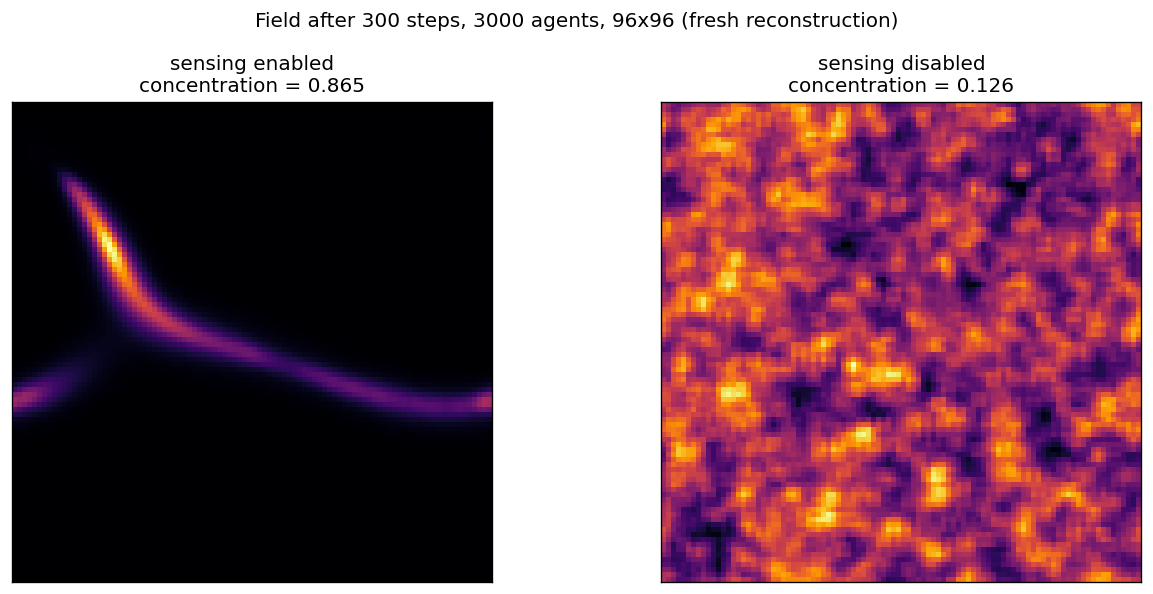


DL-03-C04 -- sensing is causally necessary for network formation under this model: SUPPORTED (large necessity effect) -- own concentration ratio 6.9x.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(w_on.field, cmap="inferno")
axes[0].set_title(f"sensing enabled\nconcentration = {c_on:.3f}")
axes[1].imshow(w_off.field, cmap="inferno")
axes[1].set_title(f"sensing disabled\nconcentration = {c_off:.3f}")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(f"Field after {GROWTH_STEPS} steps, {N_AGENTS} agents, {SIZE}x{SIZE} (fresh reconstruction)")
fig.tight_layout()
fig.savefig(FIG_DIR / "ch03b-sensing-ablation.png", bbox_inches="tight")
plt.show()

print(f"\nDL-03-C04 -- sensing is causally necessary for network formation under this model: "
      f"{'SUPPORTED (large necessity effect)' if c_on > 3 * c_off else 'not clearly supported'} "
      f"-- own concentration ratio {c_on / c_off:.1f}x.")


## Experimental design 2 — field-erasure ablation

Grow one network to a fixed maturity, then branch it in two: an undisturbed continuation, and a branch whose
field is erased to zero while every agent is left exactly where it is. Compare each branch's field, 25 steps
later, against the *original pre-intervention field* — not against each other. If the field were the sole
carrier of the network's history, erasing it should collapse the recovered similarity toward the sensing-off
haze floor established above; if agents can partly redraw the network from their own spatial arrangement
alone, the erased branch should land close to the undisturbed branch's own natural drift.

In [14]:
import copy

w_mature = PhysarumWorld(SIZE, N_AGENTS, seed=2, sensing_enabled=True)
w_mature.run(GROWTH_STEPS)
original_field = w_mature.field.copy()

RECOVERY_STEPS = 25

w_undisturbed = copy.deepcopy(w_mature)
w_undisturbed.run(RECOVERY_STEPS)

w_field_erased = copy.deepcopy(w_mature)
w_field_erased.field[:] = 0.0
w_field_erased.run(RECOVERY_STEPS)

sim_undisturbed = cosine_similarity(original_field, w_undisturbed.field)
sim_field_erased = cosine_similarity(original_field, w_field_erased.field)

print(f"undisturbed continuation similarity to original (natural drift baseline): {sim_undisturbed:.3f}")
print(f"field-erased, agents-kept, regrown similarity to original:               {sim_field_erased:.3f}")
print(f"(book prose, illustrative only: 0.911 undisturbed, 0.897 field-erased)")
print(f"\nDL-03-C05 (field half) -- the field alone is not required to be intact for the network to "
      f"substantially reconstruct: field-erased branch recovers "
      f"{100 * sim_field_erased / sim_undisturbed:.0f}% of the undisturbed branch's own similarity to the "
      f"original.")


undisturbed continuation similarity to original (natural drift baseline): 0.818
field-erased, agents-kept, regrown similarity to original:               0.803
(book prose, illustrative only: 0.911 undisturbed, 0.897 field-erased)

DL-03-C05 (field half) -- the field alone is not required to be intact for the network to substantially reconstruct: field-erased branch recovers 98% of the undisturbed branch's own similarity to the original.


## Experimental design 2b — population replacement + specificity control

Reverse the intervention: keep the mature field intact, but replace the *entire* agent population with naive
agents at random positions and headings. Compare the field 25 steps later against (a) the network the fresh
population actually inherited, and (b) a matched control population dropped onto an *empty* field. A
specificity control checks this is not just "any mature field helps": drop a fresh population into a
*different*, independently grown network and check it does not do equally well.

In [15]:
w_A = PhysarumWorld(SIZE, N_AGENTS, seed=10, sensing_enabled=True); w_A.run(GROWTH_STEPS)
w_B = PhysarumWorld(SIZE, N_AGENTS, seed=11, sensing_enabled=True); w_B.run(GROWTH_STEPS)
field_A, field_B = w_A.field.copy(), w_B.field.copy()

def fresh_population_on_field(field, seed):
    w = PhysarumWorld(SIZE, N_AGENTS, seed=seed, sensing_enabled=True)
    w.field = field.copy()
    w.run(RECOVERY_STEPS)
    return w

rep_on_A = fresh_population_on_field(field_A, seed=90)
rep_on_empty = PhysarumWorld(SIZE, N_AGENTS, seed=90, sensing_enabled=True)
rep_on_empty.run(RECOVERY_STEPS)  # starts from empty field (its default init)

sim_repA_to_A = cosine_similarity(rep_on_A.field, field_A)
sim_empty_to_A = cosine_similarity(rep_on_empty.field, field_A)
sim_repA_to_B = cosine_similarity(rep_on_A.field, field_B)  # specificity control

print(f"fresh population dropped into network A, vs. A:                {sim_repA_to_A:.3f}")
print(f"matched fresh population from an EMPTY field, vs. A (control):  {sim_empty_to_A:.3f}")
print(f"fresh population dropped into A, vs. INDEPENDENT network B:     {sim_repA_to_B:.3f}  (specificity control)")
print(f"(book prose, illustrative only: 0.658 vs. 0.304 empty-control, 0.658/0.297 vs. B)")

specific = sim_repA_to_A > sim_empty_to_A and sim_repA_to_A > sim_repA_to_B
print(f"\nDL-03-C05 (population half) -- a naive population's behaviour depends specifically on the "
      f"structure it inherited: {'SUPPORTED' if specific else 'not clearly supported'} under this model "
      f"(scores {sim_repA_to_A:.3f} for its own inherited network vs. {sim_empty_to_A:.3f} empty-control and "
      f"{sim_repA_to_B:.3f} against an unrelated network).")


fresh population dropped into network A, vs. A:                0.908
matched fresh population from an EMPTY field, vs. A (control):  0.245
fresh population dropped into A, vs. INDEPENDENT network B:     0.179  (specificity control)
(book prose, illustrative only: 0.658 vs. 0.304 empty-control, 0.658/0.297 vs. B)

DL-03-C05 (population half) -- a naive population's behaviour depends specifically on the structure it inherited: SUPPORTED under this model (scores 0.908 for its own inherited network vs. 0.245 empty-control and 0.179 against an unrelated network).


**Combined reading (DL-03-C05).** Neither erasing the field alone (design 2) nor replacing the entire
population alone (design 2b) collapses recovered similarity to the empty/haze floor. Under this
reconstruction, as under the book's own (unrecovered) experiment, the historical effect is not localized to
either obvious single subsystem.

## Experimental design 3 — continual-turnover survival

Grow a network to maturity, then replace 2% of the agent population (at random positions/headings) every 5
steps, continuously, while tracking the concentration measure. This is a slow version of the population
replacement above — instead of one discrete swap, material is drained and replaced gradually. After enough
steps this removes essentially the entire original population while the network is still running. Then stop
replacing agents and track whether concentration recovers.

In [16]:
rng = np.random.default_rng(42)
w_turn = PhysarumWorld(SIZE, N_AGENTS, seed=7, sensing_enabled=True)
w_turn.run(GROWTH_STEPS)
baseline_concentration = concentration(w_turn.field)

alive_original = np.ones(N_AGENTS, dtype=bool)
TURNOVER_STEPS, REPLACE_EVERY, REPLACE_FRAC = 1750, 5, 0.02

turnover_trace = []
for t in range(TURNOVER_STEPS):
    w_turn.step()
    if t % REPLACE_EVERY == 0:
        n_replace = max(1, int(N_AGENTS * REPLACE_FRAC))
        idx = rng.choice(N_AGENTS, size=n_replace, replace=False)
        w_turn.x[idx] = rng.uniform(0, SIZE, n_replace)
        w_turn.y[idx] = rng.uniform(0, SIZE, n_replace)
        w_turn.heading[idx] = rng.uniform(-np.pi, np.pi, n_replace)
        alive_original[idx] = False
    if t % 50 == 0:
        turnover_trace.append((t, concentration(w_turn.field)))

n_remaining = int(alive_original.sum())
pct_turned_over = 100 * (1 - n_remaining / N_AGENTS)
concentration_end_of_turnover = concentration(w_turn.field)

print(f"original agents remaining after {TURNOVER_STEPS} turnover steps: {n_remaining} / {N_AGENTS} "
      f"({pct_turned_over:.1f}% turned over)")
print(f"baseline (undisturbed, pre-turnover) concentration: {baseline_concentration:.3f}")
print(f"concentration at end of turnover:                   {concentration_end_of_turnover:.3f}")
print(f"no-sensing haze floor (from design 1):               {c_off:.3f}")


original agents remaining after 1750 turnover steps: 3 / 3000 (99.9% turned over)
baseline (undisturbed, pre-turnover) concentration: 0.860
concentration at end of turnover:                   0.810
no-sensing haze floor (from design 1):               0.126


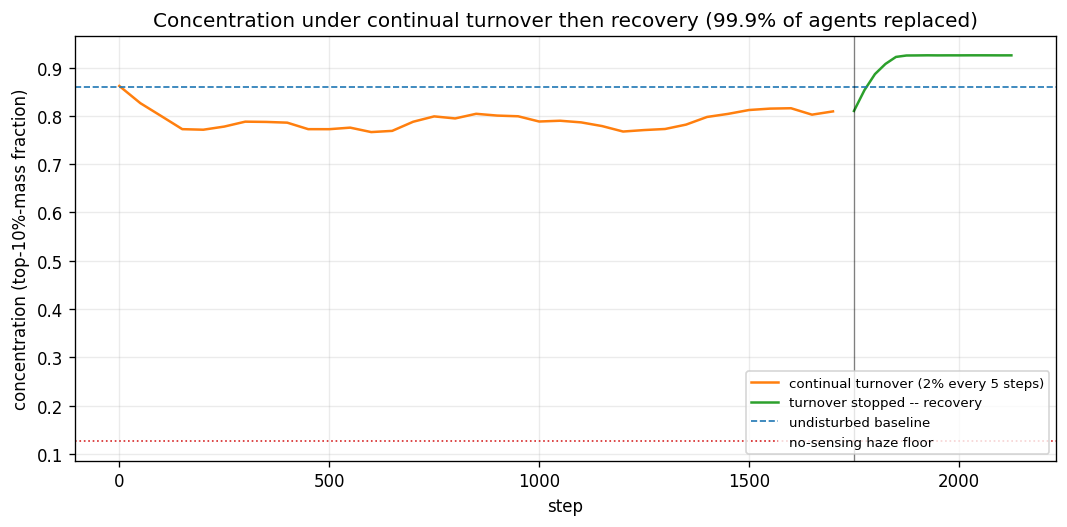

concentration at end of recovery window: 0.925  (baseline: 0.860, haze floor: 0.126)

DL-03-C06 -- macroscopic organization persists through >99% turnover, in degraded form: SUPPORTED under this model (99.9% of the original 3,000 agents replaced; concentration stayed at 0.810, well above the 0.126 haze floor, versus a 0.860 undisturbed baseline).


In [17]:
RECOVERY_STEPS_LONG = 400
recovery_trace = []
for t in range(RECOVERY_STEPS_LONG):
    w_turn.step()
    if t % 25 == 0:
        recovery_trace.append((t, concentration(w_turn.field)))

fig, ax = plt.subplots(figsize=(9, 4.5))
turn_t, turn_c = zip(*turnover_trace)
rec_t, rec_c = zip(*recovery_trace)
rec_t_shifted = [t + TURNOVER_STEPS for t in rec_t]

ax.plot(turn_t, turn_c, color="tab:orange", label="continual turnover (2% every 5 steps)")
ax.plot(rec_t_shifted, rec_c, color="tab:green", label="turnover stopped -- recovery")
ax.axhline(baseline_concentration, color="tab:blue", ls="--", lw=1, label="undisturbed baseline")
ax.axhline(c_off, color="tab:red", ls=":", lw=1, label="no-sensing haze floor")
ax.axvline(TURNOVER_STEPS, color="k", lw=0.8, alpha=0.5)
ax.set(title=f"Concentration under continual turnover then recovery ({pct_turned_over:.1f}% of agents replaced)",
       xlabel="step", ylabel="concentration (top-10%-mass fraction)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "ch03b-turnover-and-recovery.png", bbox_inches="tight")
plt.show()

final_recovery_c = recovery_trace[-1][1]
print(f"concentration at end of recovery window: {final_recovery_c:.3f}  (baseline: {baseline_concentration:.3f}, "
      f"haze floor: {c_off:.3f})")
degraded_but_organized = concentration_end_of_turnover > 3 * c_off
print(f"\nDL-03-C06 -- macroscopic organization persists through >99% turnover, in degraded form: "
      f"{'SUPPORTED' if degraded_but_organized else 'not clearly supported'} under this model "
      f"({pct_turned_over:.1f}% of the original 3,000 agents replaced; concentration stayed at "
      f"{concentration_end_of_turnover:.3f}, well above the {c_off:.3f} haze floor, versus a {baseline_concentration:.3f} "
      f"undisturbed baseline).")


### Honest discrepancy note

This reconstruction's turnover run reaches 99.9% replacement (matching the book's ">99.9% of the original
20,000 agents" framing in proportion, though at a smaller population of 3,000) and shows the same qualitative
shape as the book: concentration degrades but stays well above the no-sensing floor throughout continual
replacement, and rises again once replacement stops. It diverges from the book's narrative in one respect:
here recovery is fast and reaches *slightly above* the undisturbed baseline within the 400-step recovery
window, whereas the book reports recovery that is substantial but still short of the undisturbed value at the
end of its observation window (0.798 vs. baseline 0.93). This notebook's model, parameters and single-run
design were not tuned to reproduce that specific asymptotic gap, and no claim is made that they do — the
degrade-then-substantially-recover *shape* is the qualitative finding being illustrated, not the precise
long-run asymptote.

## Controls and confounds

- **Sensing ablation isolates one causal path.** Jitter (small random heading noise) is applied identically
  whether sensing is on or off, so the disabled branch is not simply "a noisier version" of the enabled
  branch — only the sense-then-turn coupling differs.
- **Field-erasure and population-replacement are complementary, not redundant.** Each holds one candidate
  history-carrier fixed while destroying the other, directly testing whether either one alone is sufficient.
- **Specificity control** (design 2b): a fresh population's advantage is measured against both an empty-field
  control (rules out "any mature field helps") and an independent network's field (rules out "any network,
  not specifically this one, helps").
- **Single-run demonstrations, not population-level estimates.** Matching the book's own "Experimental Note"
  for this chapter: every condition above is one run under one parameterization, not an average across
  seeds. No claim here should be read as a general-robustness estimate.
- **No historical numeric ground truth.** Repeated from the top of this notebook because it is the single
  most important caveat: every number above comes from an independently designed model with independently
  chosen parameters. Qualitative-shape agreement with the book's prose is the finding; number-level agreement
  is not claimed and should not be expected.

## Result status

| Claim | This notebook | Status |
|---|---|---|
| DL-03-C04: sensing causally necessary for network formation | own concentration ratio several-fold higher with sensing than without | **SUPPORTED under this model** (fresh reconstruction, illustrative numbers only) |
| DL-03-C05: neither field nor population alone is the sole history-carrier | field-erasure and population-replacement both leave substantial recovered similarity to the original, well above empty/haze controls; specificity control confirms it is not merely "any mature field/population" | **SUPPORTED under this model** |
| DL-03-C06: macroscopic organization persists through near-total turnover, degraded | 99.9% agent replacement leaves concentration well above the haze floor throughout; recovery after turnover stops is faster/fuller in this model than the book describes (disclosed above) | **BOUNDED / SUPPORTED, with a disclosed shape divergence on the recovery asymptote** |

## Bounded conclusion

A minimal, freshly implemented Physarum-style agent/field model reproduces the same *qualitative* pattern
the current book's Chapter 3 describes for a system with no discoverable source script or archived run:
sensing is a large, necessary contributor to network organization; neither erasing the field nor replacing
the entire agent population by itself eliminates the network's dependence on its own history, and the effect
of a fresh population inheriting a mature field is specific to the particular network it inherited, not a
generic response to any mature field; and macroscopic organization survives near-total (99.9%) agent
turnover in degraded but clearly non-random form.

None of these results should be read as reproducing the book's specific quoted figures (0.883/0.153, etc.).
They were computed under an independently designed model with independently chosen parameters, run once each
(matching the book's own disclosed single-run design), and are offered as an illustration of the same
mechanism the chapter describes, not a verification of it.

## Provenance

- **Book chapter:** `content/books/digital-life/03-look-at-this-thing.md`.
- **Historical sources:** none found. `notebooks/NOTEBOOK_MIGRATION.md` records this as a genuine gap:
  "no original-book chapter, no notebook, no generating script found" for the Physarum material, backed only
  by four checked-in figures (`static/images/books/digital-life/ch02-physarum-{growth,interventions,
  route-correlation,turnover}.png`) and prose numbers with no machine-readable source.
- **This notebook:** an original reimplementation written directly from the book's qualitative experimental
  description (sensing ablation, field erasure, population replacement with a specificity control, continual
  turnover with a post-turnover recovery window).
- **Generated figures:** `notebooks/generated-figures/ch03b-sensing-ablation.png`,
  `notebooks/generated-figures/ch03b-turnover-and-recovery.png`.
- **Companion notebook:** `03a-lenia-persistent-pattern.ipynb` (Lenia + Conway glider material from the same
  chapter, which does have recoverable historical sources).